In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('plant_disease_dataset.csv')
print("Shape:", df.shape)
print()
print(df.head())

Shape: (10000, 5)

   temperature   humidity   rainfall   soil_pH  disease_present
0    27.483571  33.215053   0.572758  4.975875                1
1    24.308678  36.945005  42.522346  8.165266                0
2    28.238443  34.026189  16.095303  6.316734                1
3    32.615149  41.104180  20.311015  6.164949                0
4    23.829233  51.971785  11.851323  8.482468                0


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      10000 non-null  float64
 1   humidity         10000 non-null  float64
 2   rainfall         10000 non-null  float64
 3   soil_pH          10000 non-null  float64
 4   disease_present  10000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 390.8 KB
None


In [6]:
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())

Data Types:
temperature        float64
humidity           float64
rainfall           float64
soil_pH            float64
disease_present      int64
dtype: object

Missing Values:
temperature        0
humidity           0
rainfall           0
soil_pH            0
disease_present    0
dtype: int64


In [7]:
df.describe()

,temperature,humidity,rainfall,soil_pH,disease_present
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.612191,62.119300,9.807522,6.245855,0.241000
std,5.813841,22.679977,9.852130,1.302465,0.427712
min,5.387999,6.244209,0.000055,4.000075,0.000000
25%,21.815610,40.772925,2.812822,5.122970,0.000000
50%,25.293238,72.211752,6.864898,6.232188,0.000000
75%,28.916048,81.032999,13.442871,7.386377,0.000000
max,56.686495,102.395421,84.654161,8.499875,1.000000


In [8]:
print("Class Counts:")
print(df['disease_present'].value_counts())
print()
print("Class Percentages:")
print(df['disease_present'].value_counts(normalize=True) * 100)

Class Counts:
disease_present
0    7590
1    2410
Name: count, dtype: int64

Class Percentages:
disease_present
0    75.9
1    24.1
Name: proportion, dtype: float64


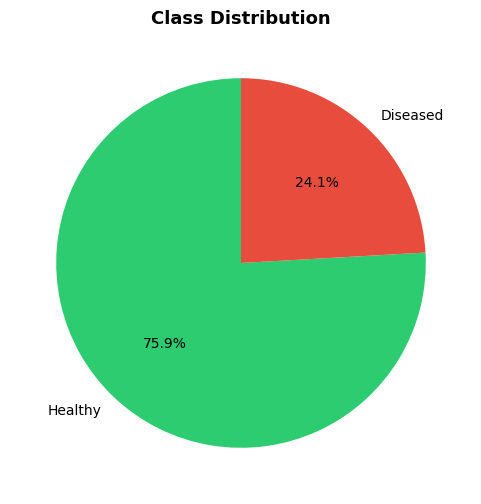

In [9]:
# Get the counts of each class (0 for healthy, 1 for diseased)
counts = df['disease_present'].value_counts().sort_index()

# Create a figure for the pie chart
plt.figure(figsize=(6, 6))

# Pie chart for class distribution
plt.pie(
    counts,
    labels=['Healthy', 'Diseased'],
    autopct='%1.1f%%',
    colors=['#2ECC71', '#E74C3C'],
    startangle=90
)

plt.title('Class Distribution', fontsize=13, fontweight='bold')
plt.show()

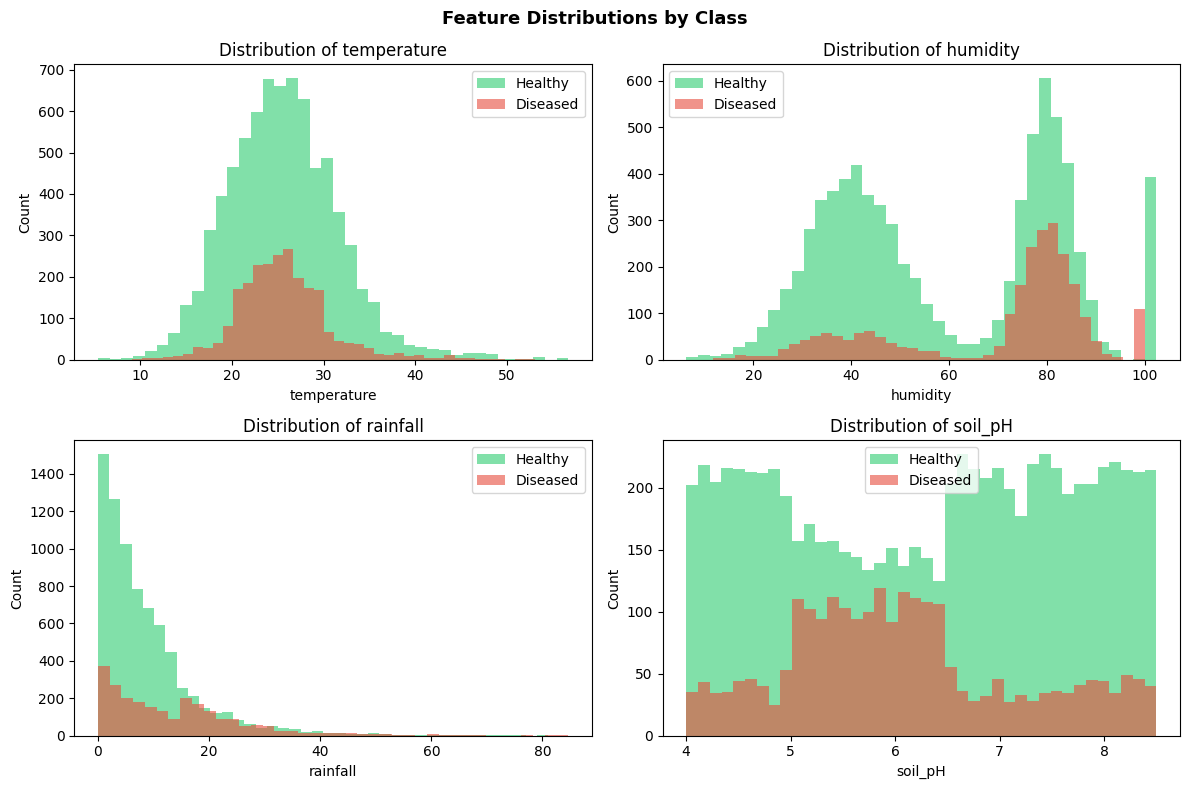

In [10]:
features = ['temperature', 'humidity', 'rainfall', 'soil_pH']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
 
for i, col in enumerate(features):
    healthy = df[df['disease_present'] == 0][col]
    diseased = df[df['disease_present'] == 1][col]
 
    axes[i].hist(healthy, bins=40, alpha=0.6, color='#2ECC71', label='Healthy')
    axes[i].hist(diseased, bins=40, alpha=0.6, color='#E74C3C', label='Diseased')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()
 
plt.suptitle('Feature Distributions by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_5216\755879283.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_5216\755879283.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Healthy', 'Diseased'])
C:\Users\user\AppData\Local\Temp\ipykernel_5216\755879283.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_5216\755879283.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Healthy', '

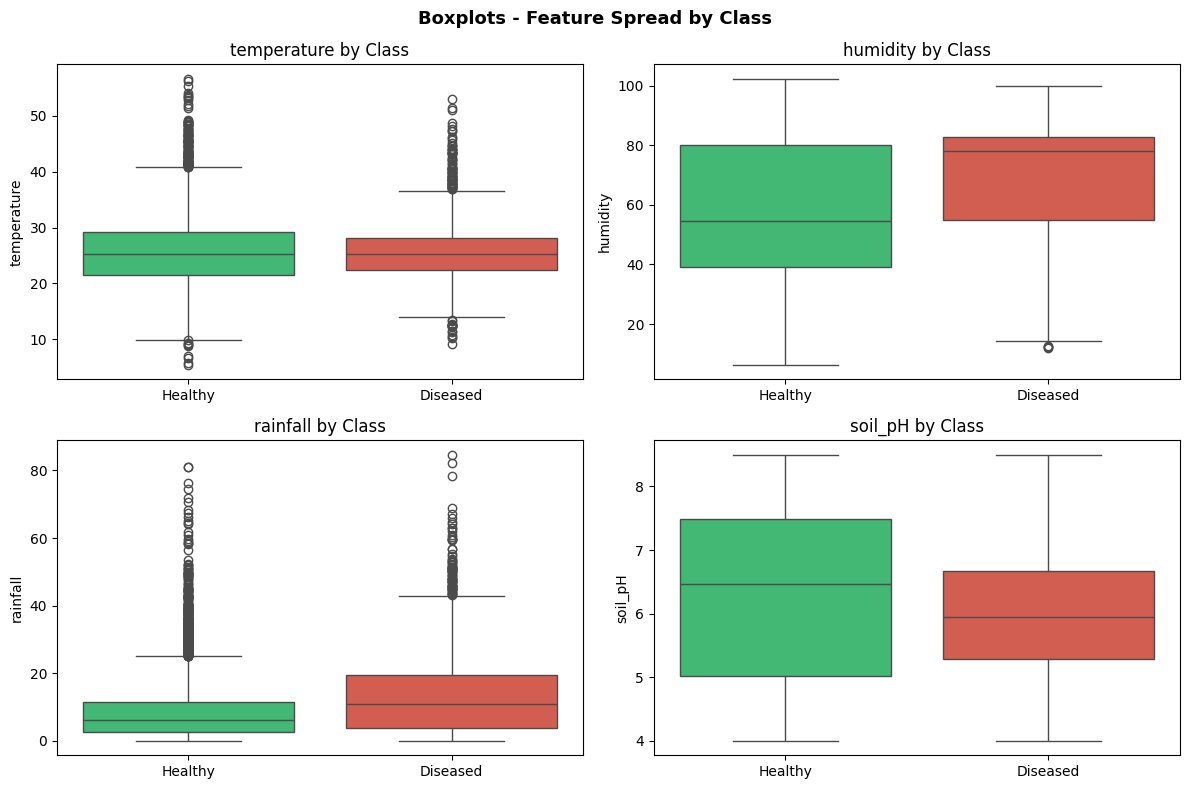

In [11]:
# Create boxplots for each feature to compare healthy vs diseased plants
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    # Use seaborn to create a simple boxplot
    sns.boxplot(
        x='disease_present',
        y=col,
        data=df,
        ax=axes[i],
        palette=['#2ECC71', '#E74C3C']
    )

    axes[i].set_title(f'{col} by Class')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(['Healthy', 'Diseased'])

plt.suptitle('Boxplots - Feature Spread by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

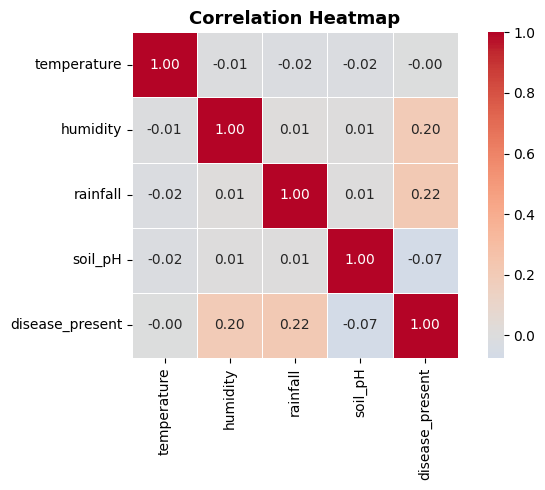

In [12]:
plt.figure(figsize=(7, 5))
 
corr = df.corr()
 
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
 
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 

In [19]:
print("Outlier counts per feature (IQR method):\n")
 
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"  {col}: {outlier_count} outliers  (lower < {lower_bound:.2f}, upper > {upper_bound:.2f})")
 
print()
print(f"Humidity > 100% : {(df['humidity'] > 100).sum()} rows")
print(f"Temperature > 50°C : {(df['temperature'] > 50).sum()} rows")
 

Outlier counts per feature (IQR method):

  temperature: 245 outliers  (lower < 11.16, upper > 39.57)
  humidity: 0 outliers  (lower < -19.62, upper > 141.42)
  rainfall: 496 outliers  (lower < -13.13, upper > 29.39)
  soil_pH: 0 outliers  (lower < 1.73, upper > 10.78)

Humidity > 100% : 1 rows
Temperature > 50°C : 15 rows


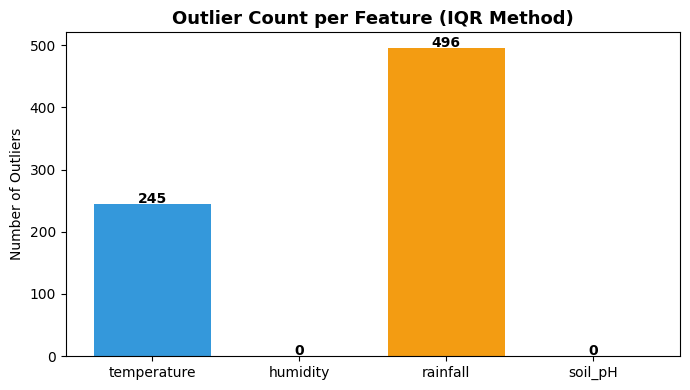

In [20]:
outlier_counts = {}
 
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_counts[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
 
plt.figure(figsize=(7, 4))
plt.bar(outlier_counts.keys(), outlier_counts.values(), color=['#3498DB', '#9B59B6', '#F39C12', '#1ABC9C'])
plt.ylabel('Number of Outliers')
plt.title('Outlier Count per Feature (IQR Method)', fontsize=13, fontweight='bold')
 
for i, (col, v) in enumerate(outlier_counts.items()):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
 
plt.tight_layout()
plt.show()

In [21]:
print("Mean values grouped by class:\n")
print(df.groupby('disease_present')[features].mean().round(3))

Mean values grouped by class:

                 temperature  humidity  rainfall  soil_pH
disease_present                                          
0                     25.615    59.573     8.594    6.300
1                     25.603    70.138    13.629    6.075
